## Script for generation of plots for rebuttal of paper with Stefan
- Scripts are taken from the ouput of the EHRSHOT Code

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter
import os

In [2]:
## check if folder "Results_Paper" exists, if not create it
if not os.path.exists("../Results_new"):
    os.makedirs("../Results_new")

In [3]:
data_full = {
    "Model": [
        "Full EHR",
        "Empty Instruction",
        "Generic Instruction",
        "No Demographics",
        "No Visits",
        "No Conditions",
        "No Medications",
        "No Procedures",
        "No Lab Results",
        "Only Demographics",
        "Only Visits",
        "Only Conditions",
        "Only Medications",
        "Only Procedures",
        "Only Lab Results"
    ],
    "Size": ["8B", "8B","8B","8B","8B","8B","8B","8B","8B", "8B","8B","8B","8B","8B","8B"],

    "Operational Outcomes": [
        0.797, 0.791, 0.788, 0.797, 0.796, 0.797, 0.798, 0.787, 0.798, 
        0.549, 0.591, 0.773, 0.777, 0.781, 0.777],

    "Operational Outcomes_lower": [
        0.773, 0.767, 0.765, 0.774, 0.773, 0.774, 0.775, 0.764, 0.775,
        0.518, 0.564, 0.750, 0.756, 0.756, 0.755
    ],

    "Operational Outcomes_upper": [
        0.820, 0.815, 0.812, 0.820, 0.819, 0.820, 0.822, 0.810, 0.821,
        0.580, 0.618, 0.797, 0.799, 0.807, 0.799
    ],

    "Anticipating Lab Test Results": [
        0.842, 0.756, 0.772, 0.842, 0.842, 0.847, 0.846, 0.847, 0.752,
        0.543, 0.628, 0.708, 0.710, 0.718, 0.856
    ],

    "Anticipating Lab Test Results_lower": [
        0.835, 0.745, 0.762, 0.834, 0.835, 0.840, 0.838, 0.839, 0.741,
        0.528, 0.615, 0.695, 0.698, 0.705, 0.849
    ],

    "Anticipating Lab Test Results_upper": [
        0.850, 0.766, 0.782, 0.849, 0.849, 0.854, 0.853, 0.854, 0.763,
        0.559, 0.642, 0.721, 0.722, 0.731, 0.862
    ],

    "Assignment of New Diagnosis": [
        0.714, 0.698, 0.706, 0.708, 0.717, 0.701, 0.702, 0.721, 0.722,
        0.606, 0.560, 0.693, 0.688, 0.672, 0.665
    ],

    "Assignment of New Diagnosis_lower": [
        0.672, 0.651, 0.665, 0.666, 0.676, 0.665, 0.657, 0.678, 0.681,
        0.570, 0.523, 0.649, 0.641, 0.640, 0.607
    ],

    "Assignment of New Diagnosis_upper": [
        0.757, 0.745, 0.747, 0.750, 0.758, 0.737, 0.746, 0.764, 0.762,
        0.643, 0.596, 0.737, 0.735, 0.704, 0.724
    ],

    "Anticipating Chest X-ray Findings": [
        0.722, 0.715, 0.718, 0.721, 0.723, 0.716, 0.722, 0.718, 0.711,
        0.513, 0.613, 0.686, 0.657, 0.697, 0.702
    ],

    "Anticipating Chest X-ray Findings_lower": [
        0.711, 0.704, 0.707, 0.710, 0.712, 0.705, 0.711, 0.707, 0.699,
        0.494, 0.600, 0.673, 0.644, 0.685, 0.691
    ],

    "Anticipating Chest X-ray Findings_upper": [
        0.733, 0.726, 0.730, 0.732, 0.734, 0.727, 0.733, 0.729, 0.722,
        0.531, 0.625, 0.698, 0.670, 0.708, 0.713
    ],

    # "Macro average": [
    #     0.769, 0.740, 0.746, 0.767, 0.769, 0.765, 0.767, 0.768, 0.746,
    #     0.553, 0.598, 0.715, 0.708, 0.717, 0.750
    # ],

    # "Macro average_lower": [
    #     0.744, 0.712, 0.722, 0.742, 0.745, 0.743, 0.741, 0.743, 0.721,
    #     0.526, 0.574, 0.688, 0.681, 0.695, 0.718
    # ],

    # "Macro average_upper": [
    #     0.794, 0.767, 0.771, 0.792, 0.794, 0.788, 0.793, 0.793, 0.770,
    #     0.579, 0.622, 0.741, 0.735, 0.739, 0.782
    # ]
}
df_full = pd.DataFrame(data_full)
df_full

,Model,Size,Operational Outcomes,Operational Outcomes_lower,Operational Outcomes_upper,Anticipating Lab Test Results,Anticipating Lab Test Results_lower,Anticipating Lab Test Results_upper,Assignment of New Diagnosis,Assignment of New Diagnosis_lower,Assignment of New Diagnosis_upper,Anticipating Chest X-ray Findings,Anticipating Chest X-ray Findings_lower,Anticipating Chest X-ray Findings_upper
0,Full EHR,8B,0.797,0.773,0.820,0.842,0.835,0.850,0.714,0.672,0.757,0.722,0.711,0.733
1,Empty Instruction,8B,0.791,0.767,0.815,0.756,0.745,0.766,0.698,0.651,0.745,0.715,0.704,0.726
2,Generic Instruction,8B,0.788,0.765,0.812,0.772,0.762,0.782,0.706,0.665,0.747,0.718,0.707,0.730
3,No Demographics,8B,0.797,0.774,0.820,0.842,0.834,0.849,0.708,0.666,0.750,0.721,0.710,0.732
4,No Visits,8B,0.796,0.773,0.819,0.842,0.835,0.849,0.717,0.676,0.758,0.723,0.712,0.734
5,No Conditions,8B,0.797,0.774,0.820,0.847,0.840,0.854,0.701,0.665,0.737,0.716,0.705,0.727
6,No Medications,8B,0.798,0.775,0.822,0.846,0.838,0.853,0.702,0.657,0.746,0.722,0.711,0.733
7,No Procedures,8B,0.787,0.764,0.810,0.847,0.839,0.854,0.721,0.678,0.764,0.718,0.707,0.729
8,No Lab Results,8B,0.798,0.775,0.821,0.752,0.741,0.763,0.722,0.681,0.762,0.711,0.699,0.722
9,Only Demographics,8B,0.549,0.518,0.580,0.543,0.528,0.559,0.606,0.570,0.643,0.513,0.494,0.531


In [4]:
# change row order in df_full so generict instruction and without instruction are switched
df_full = df_full.iloc[[0,2,1,3,4,5,6,7,8,9,10,11,12,13,14]].reset_index(drop=True)
df_full

,Model,Size,Operational Outcomes,Operational Outcomes_lower,Operational Outcomes_upper,Anticipating Lab Test Results,Anticipating Lab Test Results_lower,Anticipating Lab Test Results_upper,Assignment of New Diagnosis,Assignment of New Diagnosis_lower,Assignment of New Diagnosis_upper,Anticipating Chest X-ray Findings,Anticipating Chest X-ray Findings_lower,Anticipating Chest X-ray Findings_upper
0,Full EHR,8B,0.797,0.773,0.820,0.842,0.835,0.850,0.714,0.672,0.757,0.722,0.711,0.733
1,Generic Instruction,8B,0.788,0.765,0.812,0.772,0.762,0.782,0.706,0.665,0.747,0.718,0.707,0.730
2,Empty Instruction,8B,0.791,0.767,0.815,0.756,0.745,0.766,0.698,0.651,0.745,0.715,0.704,0.726
3,No Demographics,8B,0.797,0.774,0.820,0.842,0.834,0.849,0.708,0.666,0.750,0.721,0.710,0.732
4,No Visits,8B,0.796,0.773,0.819,0.842,0.835,0.849,0.717,0.676,0.758,0.723,0.712,0.734
5,No Conditions,8B,0.797,0.774,0.820,0.847,0.840,0.854,0.701,0.665,0.737,0.716,0.705,0.727
6,No Medications,8B,0.798,0.775,0.822,0.846,0.838,0.853,0.702,0.657,0.746,0.722,0.711,0.733
7,No Procedures,8B,0.787,0.764,0.810,0.847,0.839,0.854,0.721,0.678,0.764,0.718,0.707,0.729
8,No Lab Results,8B,0.798,0.775,0.821,0.752,0.741,0.763,0.722,0.681,0.762,0.711,0.699,0.722
9,Only Demographics,8B,0.549,0.518,0.580,0.543,0.528,0.559,0.606,0.570,0.643,0.513,0.494,0.531


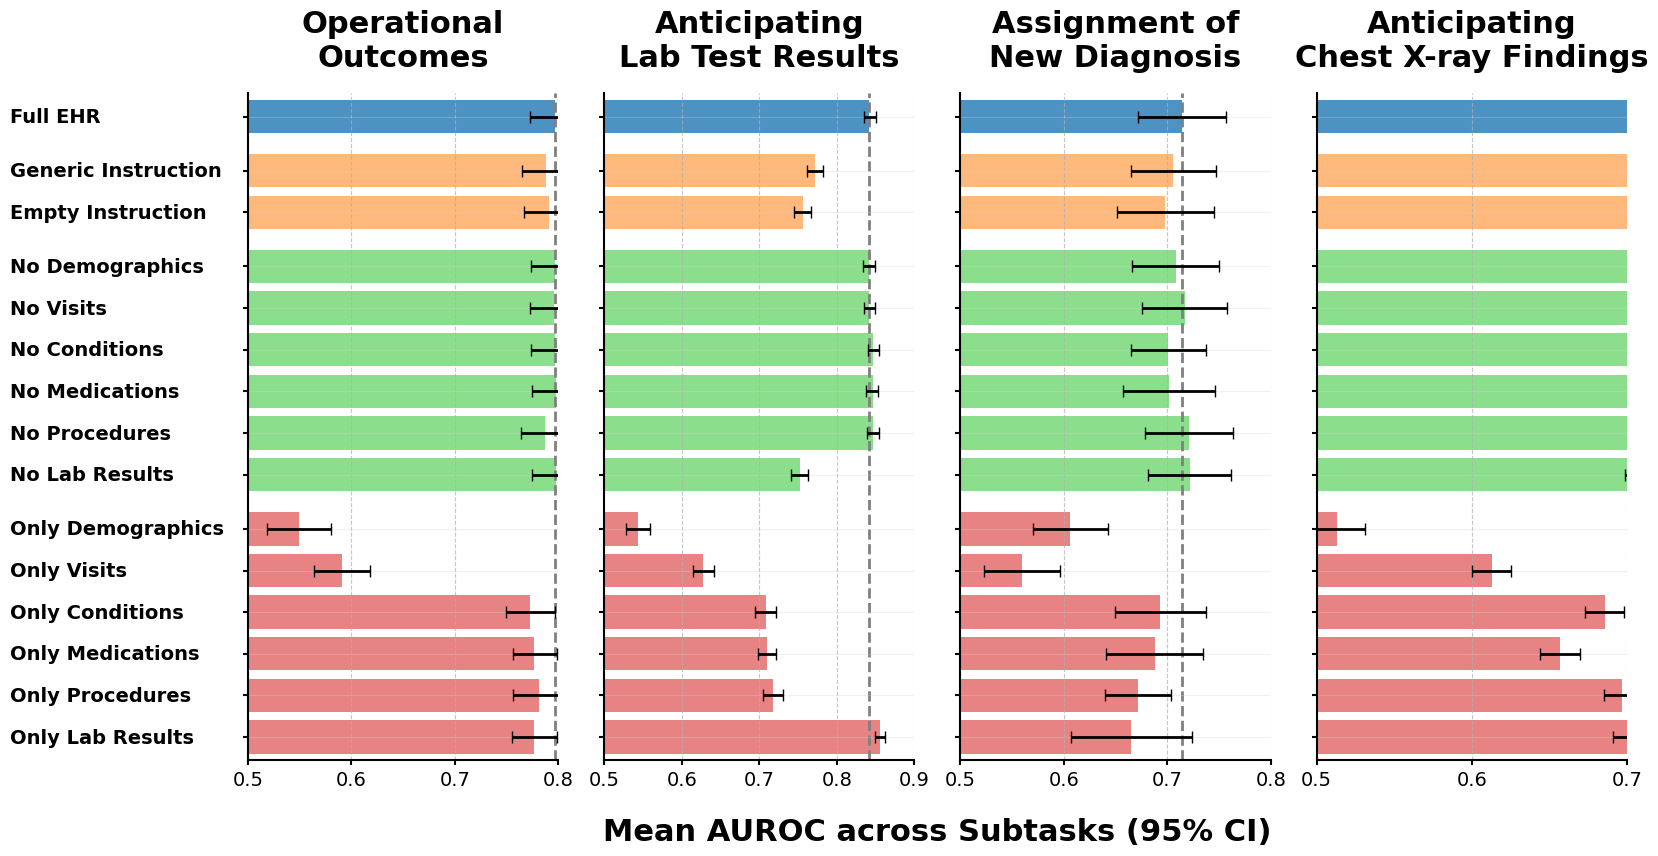

In [5]:
def plot_df(df):
    # Reorder so that baseline (complete information) is first, then reverse to put it on top
    baseline = "Full EHR"

    color1 = "#1f77b4"
    color2 = "#ffa85c"
    color3 = "#6ED870"
    color4 = "#E36464"

    group_sizes = [6, 6, 2, 1]
    gap = 0.3

    y_positions = []
    current_y = 0
    for g in group_sizes:
        y_positions.extend(current_y + np.arange(g))
        current_y += g + gap  # add gap after each group


    df = pd.concat([df[df["Model"] == baseline], df[df["Model"] != baseline]])
    # Reverse the order so baseline appears at the top of the plot
    df = df.iloc[::-1].reset_index(drop=True)
    # Metrics to plot
    metrics = ["Operational Outcomes", "Anticipating Lab Test Results", "Assignment of New Diagnosis", "Anticipating Chest X-ray Findings"]
    Header_metric = {
        "Operational Outcomes": "Operational\nOutcomes",
        "Anticipating Lab Test Results": "Anticipating\nLab Test Results",
        "Assignment of New Diagnosis": "Assignment of\nNew Diagnosis",
        "Anticipating Chest X-ray Findings": "Anticipating\nChest X-ray Findings"
    }
    # Define x-ranges for each plot
    x_ranges = [(0.5, 0.8), (0.5, 0.9), (0.5, 0.8), (0.5, 0.7)]
    # Create figure with subplots
    fig, axes = plt.subplots(1, 4, figsize=(16, 9), sharey=True)

    
    for i, (ax, metric) in enumerate(zip(axes, metrics)):
        #y_positions = range(len(df))
        ax.barh(y_positions, df[metric], color="white", alpha=0) # invisible bars to set y-axis
        df[f"{metric}_err_low"] = df[metric] - df[f"{metric}_lower"]
        df[f"{metric}_err_up"] = df[f"{metric}_upper"] - df[metric]
        # Draw baseline vertical line
        baseline_value = df.loc[df["Model"] == baseline, metric].values[0]
        ax.axvline(baseline_value, color="grey", linestyle="--", linewidth=2) # draw vertical line at baseline
        # Formatting - use specific x-range for each plot
        x_min, x_max = x_ranges[i]
        ax.set_xlim(x_min, x_max)
        #ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))  # eine Nachkommastelle

        # Set appropriate x-ticks based on the range
        if x_max == 0.70:
            ax.set_xticks([0.5, 0.6, 0.7])
        elif x_max == 0.8:
            ax.set_xticks([0.5, 0.6, 0.7, 0.8])
        elif x_max == 0.9:
            ax.set_xticks([0.5, 0.6, 0.7, 0.8, 0.9])

        ax.tick_params(axis="x", labelsize=14, width=1.5)  # change 12 to desired font size
        ax.tick_params(axis="y", labelsize=14, width=1.5)  # change 12 to desired font size
        # Move metric label to top instead of bottom
        ax.set_title(Header_metric[metric], fontsize=22, pad=20, fontweight='bold')
        # Add shallow horizontal lines at each y position
        for y in y_positions:
            ax.axhline(y, color="lightgray", linestyle="-", alpha=0.3, linewidth=0.8)
        colors = [color4]*6 + [color3]*6 + [color2]*2 + [color1]*1

        ax.grid(axis="x", linestyle="--", alpha=0.7) # light vertical gridlines
        # First bar
        ax.barh(
            y_positions[-1:],           # first bar
            df[metric].iloc[-1:],
            xerr=[df[f"{metric}_err_low"].iloc[-1:], df[f"{metric}_err_up"].iloc[-1:]],
            capsize=4,
            color=colors[-1:],
            alpha=0.8,                  # fully opaque
            ecolor="black",
            error_kw=dict(linewidth=2)
        )

        # Remaining bars
        ax.barh(
            y_positions[0:-1],            # remaining bars
            df[metric].iloc[0:-1],
            xerr=[df[f"{metric}_err_low"].iloc[0:-1], df[f"{metric}_err_up"].iloc[0:-1]],
            capsize=4,
            color=colors[0:-1],
            alpha=0.8,                  # semi-transparent
            ecolor="black",
            error_kw=dict(linewidth=2)
        )
        # Remove top and right spines (borders)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_linewidth(1.5)  # x-axis
        ax.spines['left'].set_linewidth(1.5)    # y-axis
        # Always set yticks for all subplots
        ax.set_yticks(y_positions)
        # Show model names on the leftmost plot only
        if i == 0: # only first subplot shows model names
            ax.set_yticklabels(df["Model"])
        else:
            ax.set_yticklabels([]) # hide on other subplots
        ax.margins(y=0.01)

    #fig.suptitle("AUROC performance leaving out specific information", fontsize=16)
    # Add text at the bottom center of the figure
    fig.text(0.5, 0.01, f"Mean AUROC across Subtasks (95% CI)",
             ha='center', fontsize=22, fontweight='bold')
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95]) # Increased left margin for model names
    # Add model names manually aligned with each bar using the first axis coordinates
    ax0 = axes[0]
    for j, model_name in enumerate(df["Model"]):
        # Use axis coordinates to properly align with bars
        ax0.text(0.27, y_positions[j], model_name, verticalalignment='center',
                 horizontalalignment='left', fontsize=14,
                 transform=ax0.transData, fontweight='bold')
    fig.savefig("../Results_new/Ablations.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_df(df_full)